<a href="https://colab.research.google.com/github/ruthzu/DS/blob/main/final_data_analysis_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hotel Booking Analysis (Advanced Techniques)

Dataset focus: cancellations, pricing, and booking behavior. This notebook applies multi-dimensional analysis, statistical validation, segmentation, cohort trends, outlier investigation, and missing-data patterns.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "hotel_booking.csv"
df_raw = pd.read_csv(DATA_PATH)
print("rows", len(df_raw), "cols", df_raw.shape[1])
df_raw.head()

rows 119390 cols 36


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [ ]:
# Basic cleaning + feature engineering
df = df_raw.copy()
pii_cols = ["name", "email", "phone-number", "credit_card"]
df = df.drop(columns=[c for c in pii_cols if c in df.columns])

df["children"] = df["children"].fillna(0)
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
month_map = {m: i for i, m in enumerate(month_order, start=1)}
df["arrival_month"] = df["arrival_date_month"].map(month_map)
df["arrival_date"] = pd.to_datetime(
    dict(
        year=df["arrival_date_year"],
        month=df["arrival_month"],
        day=df["arrival_date_day_of_month"],
    ),
)

df["stay_nights"] = df["stays_in_week_nights"] + df["stays_in_weekend_nights"]
df["total_guests"] = df["adults"] + df["children"] + df["babies"]
df["revenue_proxy"] = df["adr"] * df["stay_nights"]
df["lead_bucket"] = pd.qcut(df["lead_time"], 4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="drop")

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_month,arrival_date,stay_nights,total_guests,revenue_proxy,lead_bucket
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,0,Check-Out,2015-07-01,7,2015-07-01,0,2.0,0.0,Q4
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,0,Check-Out,2015-07-01,7,2015-07-01,0,2.0,0.0,Q4
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,0,Check-Out,2015-07-02,7,2015-07-01,1,1.0,75.0,Q1
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,0,Check-Out,2015-07-02,7,2015-07-01,1,1.0,75.0,Q1
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,1,Check-Out,2015-07-03,7,2015-07-01,2,2.0,196.0,Q1


In [ ]:
# Missing data pattern (not just cleanup)
missing = df.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
missing.head(10)

,0
company,0.943069
agent,0.136862
country,0.004087


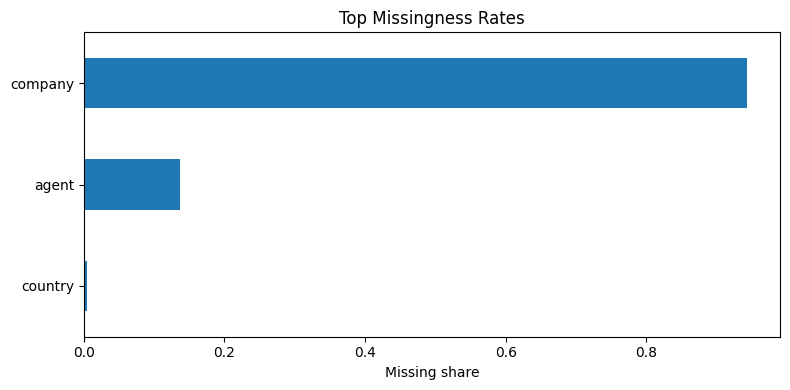

In [ ]:
plt.figure(figsize=(8, 4))
missing.head(10).sort_values().plot(kind="barh")
plt.title("Top Missingness Rates")
plt.xlabel("Missing share")
plt.tight_layout()

In [ ]:
# Baseline cancellation rates
cancel_rate = df["is_canceled"].mean()
cancel_by_hotel = df.groupby("hotel")["is_canceled"].mean().sort_values()
cancel_rate, cancel_by_hotel

(np.float64(0.37041628277075134),
 hotel
 Resort Hotel    0.277634
 City Hotel      0.417270
 Name: is_canceled, dtype: float64)

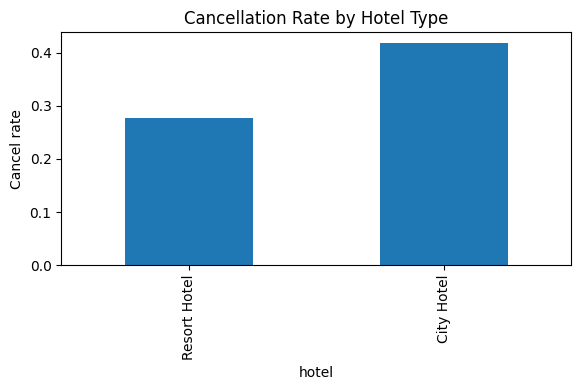

In [ ]:
plt.figure(figsize=(6, 4))
cancel_by_hotel.plot(kind="bar")
plt.title("Cancellation Rate by Hotel Type")
plt.ylabel("Cancel rate")
plt.tight_layout()

## Advanced Technique 1: Cross-Tabulation
Market segment vs deposit type vs cancellation.

In [ ]:
pivot = df.pivot_table(
    index="market_segment",
    columns="deposit_type",
    values="is_canceled",
    aggfunc="mean"
)
display(pivot.sort_values(by=pivot.columns.tolist(), ascending=False).head(10))

deposit_type,No Deposit,Non Refund,Refundable
market_segment,,,
Undefined,1.000000,NaN,NaN
Online TA,0.366434,0.946429,1.000000
Groups,0.282996,0.993240,0.100000
Aviation,0.219409,NaN,NaN
Offline TA/TO,0.172107,0.999401,0.500000
Direct,0.152293,0.842105,0.333333
Corporate,0.136978,0.934132,0.250000
Complementary,0.130552,NaN,NaN


## Advanced Technique 2: Multi-Dimensional Analysis
Hotel x market segment x lead-time bucket.

In [ ]:
multi = (
    df.groupby(["hotel", "market_segment", "lead_bucket"], observed=False)["is_canceled"]
    .mean()
    .reset_index()
)
display(multi.sort_values("is_canceled", ascending=False).head(10))

,hotel,market_segment,lead_bucket,is_canceled
28,City Hotel,Undefined,Q1,1.000000
19,City Hotel,Groups,Q4,0.829213
1,City Hotel,Aviation,Q2,0.714286
11,City Hotel,Corporate,Q4,0.657143
18,City Hotel,Groups,Q3,0.645303
50,Resort Hotel,Groups,Q3,0.580321
59,Resort Hotel,Online TA,Q4,0.563177
23,City Hotel,Offline TA/TO,Q4,0.557356
17,City Hotel,Groups,Q2,0.526155
10,City Hotel,Corporate,Q3,0.524590


## Advanced Technique 3: Percentile Analysis
Percentiles reveal distribution differences that averages hide.

In [ ]:
adr_pcts = df.groupby("hotel")["adr"].quantile([0.5, 0.9]).unstack()
display(adr_pcts)

,0.5,0.9
hotel,,
City Hotel,99.9,156.303
Resort Hotel,75.0,189.000


In [ ]:
rev_pcts = (
    df.groupby("market_segment")["revenue_proxy"]
    .quantile([0.5, 0.9])
    .unstack()
)
display(rev_pcts.sort_values(0.9, ascending=False).head(10))

,0.5,0.9
market_segment,,
Direct,252.00,964.625
Aviation,240.00,880.000
Online TA,340.35,820.800
Offline TA/TO,256.80,660.000
Groups,190.00,428.000
Corporate,90.00,300.000
Undefined,24.00,33.600
Complementary,0.00,0.000


## Advanced Technique 4: Cohort (Time) Analysis
Monthly arrival cohorts and cancellation trends.

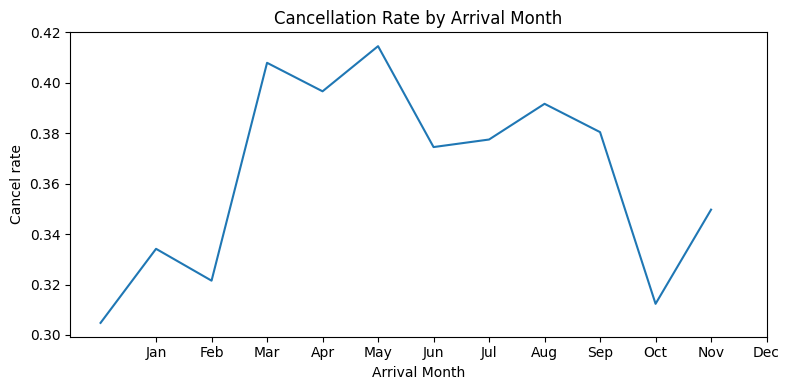

In [ ]:
monthly = df.groupby("arrival_month")["is_canceled"].mean().reset_index()
monthly = monthly.sort_values("arrival_month")

plt.figure(figsize=(8, 4))
monthly["is_canceled"].plot()
plt.title("Cancellation Rate by Arrival Month")
plt.ylabel("Cancel rate")
plt.xlabel("Arrival Month")
plt.xticks(ticks=monthly["arrival_month"], labels=[month_order[i-1][:3] for i in monthly["arrival_month"]])
plt.tight_layout()

## Advanced Technique 5: Outlier Investigation
Top spenders can drive a large share of revenue.

In [ ]:
rev = df["revenue_proxy"].copy()
rev = rev[rev > 0]
cut = rev.quantile(0.95)
top_share = rev[rev >= cut].sum() / rev.sum()
print(f"The 95th percentile for revenue proxy is {cut:.2f}.")
print(f"The top 5% of bookings contribute {top_share:.2%} of the total revenue.")

The 95th percentile for revenue proxy is 1009.66.
The top 5% of bookings contribute 19.79% of the total revenue.


## Advanced Technique 6: Ratio and Derived Metrics
Revenue per guest highlights efficiency.

In [ ]:
df["revenue_per_guest"] = df["revenue_proxy"] / df["total_guests"].replace(0, np.nan)
rpg = df.groupby("hotel")["revenue_per_guest"].median()
display(rpg)

,revenue_per_guest
hotel,
City Hotel,141.0
Resort Hotel,144.0


## Advanced Technique 7: Missingness as Signal
When a field is missing, outcomes can shift.

In [ ]:
company_missing = df["company"].isna().astype(int)
display(df.groupby(company_missing)["is_canceled"].mean())

,is_canceled
company,
0,0.175224
1,0.382200


## Advanced Technique 8: Statistical Validation (Permutation + Bootstrap)
We test if cancellation rates differ by deposit type and by lead-time bucket.

In [ ]:
def chi_square_stat(table: np.ndarray) -> float:
    row_sums = table.sum(axis=1, keepdims=True)
    col_sums = table.sum(axis=0, keepdims=True)
    total = table.sum()
    expected = row_sums @ col_sums / total
    return ((table - expected) ** 2 / expected).sum()

def permutation_test_categorical_binary(cat, y, n_perm=500, random_state=42):
    rng = np.random.default_rng(random_state)
    categories = pd.Series(cat).astype(str)
    y = np.asarray(y)
    table = pd.crosstab(categories, y).values
    stat_obs = chi_square_stat(table)

    stats = []
    for _ in range(n_perm):
        y_perm = rng.permutation(y)
        table_perm = pd.crosstab(categories, y_perm).values
        stats.append(chi_square_stat(table_perm))
    stats = np.asarray(stats)
    p_value = (stats >= stat_obs).mean()
    return stat_obs, p_value

stat_obs, p_val = permutation_test_categorical_binary(df["deposit_type"], df["is_canceled"])
print(f"Permutation Test for Deposit Type vs. Cancellation:")
print(f"  Observed Chi-Square Statistic: {stat_obs:.2f}")
print(f"  P-value: {p_val:.4f}")

Permutation Test for Deposit Type vs. Cancellation:
  Observed Chi-Square Statistic: 27677.33
  P-value: 0.0000


In [ ]:
def bootstrap_diff(a, b, n_boot=2000, random_state=42):
    rng = np.random.default_rng(random_state)
    a = np.asarray(a)
    b = np.asarray(b)
    diffs = []
    for _ in range(n_boot):
        a_s = rng.choice(a, size=len(a), replace=True)
        b_s = rng.choice(b, size=len(b), replace=True)
        diffs.append(a_s.mean() - b_s.mean())
    diffs = np.asarray(diffs)
    return diffs.mean(), np.quantile(diffs, [0.025, 0.975])

q1 = df[df["lead_bucket"] == "Q1"]["is_canceled"]
q4 = df[df["lead_bucket"] == "Q4"]["is_canceled"]
diff_mean, diff_ci = bootstrap_diff(q4, q1)
print(f"Bootstrap Test for Cancellation Rate Difference (Q4 - Q1 Lead Time):")
print(f"  Mean Difference: {diff_mean:.4f}")
print(f"  95% Confidence Interval: [{diff_ci[0]:.4f}, {diff_ci[1]:.4f}]")

Bootstrap Test for Cancellation Rate Difference (Q4 - Q1 Lead Time):
  Mean Difference: 0.4081
  95% Confidence Interval: [0.4011, 0.4151]


## Advanced Technique 9: Causal-Leaning Robustness
We standardize cancellation rates to the same lead-time (and deposit) mix to test whether gaps persist after controlling for confounders.

In [ ]:
def standardized_rate(df, group_col, outcome, strata_cols):
    weights = df.groupby(strata_cols).size()
    weights = weights / weights.sum()
    rates = {}
    for g, gdf in df.groupby(group_col):
        g_mean = gdf.groupby(strata_cols)[outcome].mean()
        aligned = pd.concat([g_mean, weights], axis=1).dropna()
        rates[g] = (aligned.iloc[:, 0] * aligned.iloc[:, 1]).sum()
    return pd.Series(rates).sort_values(ascending=False)

def bootstrap_diff_rate(a, b, n_boot=2000, random_state=42):
    rng = np.random.default_rng(random_state)
    a = np.asarray(a)
    b = np.asarray(b)
    diffs = []
    ratios = []
    for _ in range(n_boot):
        a_s = rng.choice(a, size=len(a), replace=True)
        b_s = rng.choice(b, size=len(b), replace=True)
        diffs.append(a_s.mean() - b_s.mean())
        ratios.append(a_s.mean() / b_s.mean())
    diffs = np.asarray(diffs)
    ratios = np.asarray(ratios)
    diff_ci = np.quantile(diffs, [0.025, 0.975])
    ratio_ci = np.quantile(ratios, [0.025, 0.975])
    return diffs.mean(), diff_ci, ratios.mean(), ratio_ci

unadj = df.groupby("hotel")["is_canceled"].mean()
adj_lead = standardized_rate(df, "hotel", "is_canceled", ["lead_bucket"])
adj_lead_deposit = standardized_rate(df, "hotel", "is_canceled", ["lead_bucket", "deposit_type"])

hotel_a = "City Hotel"
hotel_b = "Resort Hotel"
a = df[df["hotel"] == hotel_a]["is_canceled"]
b = df[df["hotel"] == hotel_b]["is_canceled"]
diff_mean, diff_ci, ratio_mean, ratio_ci = bootstrap_diff_rate(a, b)

print("Unadjusted Cancellation Rates by Hotel:")
display(unadj)
print("\nLead-Time Adjusted Cancellation Rates by Hotel:")
display(adj_lead)
print("\nLead-Time and Deposit Type Adjusted Cancellation Rates by Hotel:")
display(adj_lead_deposit)

print(f"\nBootstrap Test for Cancellation Rate Difference (City Hotel vs. Resort Hotel):")
print(f"  Mean Difference (City - Resort): {diff_mean:.4f}")
print(f"  95% Confidence Interval for Difference: [{diff_ci[0]:.4f}, {diff_ci[1]:.4f}]")
print(f"  Mean Ratio (City / Resort): {ratio_mean:.4f}")
print(f"  95% Confidence Interval for Ratio: [{ratio_ci[0]:.4f}, {ratio_ci[1]:.4f}]")

/tmp/ipykernel_6755/3646563400.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weights = df.groupby(strata_cols).size()
/tmp/ipykernel_6755/3646563400.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g_mean = gdf.groupby(strata_cols)[outcome].mean()
/tmp/ipykernel_6755/3646563400.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g_mean = gdf.groupby(strata_cols)[outcome].mean()
/tmp/ipykernel_6755/3646563400.py:

Unadjusted Cancellation Rates by Hotel:


,is_canceled
hotel,
City Hotel,0.417270
Resort Hotel,0.277634



Lead-Time Adjusted Cancellation Rates by Hotel:


,0
City Hotel,0.408763
Resort Hotel,0.292352



Lead-Time and Deposit Type Adjusted Cancellation Rates by Hotel:


,0
City Hotel,0.387498
Resort Hotel,0.340410



Bootstrap Test for Cancellation Rate Difference (City Hotel vs. Resort Hotel):
  Mean Difference (City - Resort): 0.1397
  95% Confidence Interval for Difference: [0.1344, 0.1451]
  Mean Ratio (City / Resort): 1.5037
  95% Confidence Interval for Ratio: [1.4782, 1.5301]
